# Regional Momentum Factor Analysis

Download **total market return** (`Mkt = Mkt-RF + RF`) and **momentum** (`WML`) from the [Ken French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) for:

- North America
- Europe
- Asia ex Japan
- Japan

Each regional dataset is stored in a pandas DataFrame indexed by **month-end date**.

In [12]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "ken_french.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ken_french import REGIONS, load_regional_factors

DATA_DIR = PROJECT_ROOT / "data" / "ken_french"
DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:8.2f}")

## Download and load regional factors

For each region we merge two Ken French CSV files:

| File | Key columns |
|------|-------------|
| Regional 3-Factor | `Mkt-RF`, `SMB`, `HML`, `RF` |
| Regional Momentum | `WML` (Winners Minus Losers) |

We compute **total market return** as `Mkt = Mkt-RF + RF`.

In [13]:
regional_factors: dict[str, pd.DataFrame] = {}

for region_key, meta in REGIONS.items():
    df = load_regional_factors(region_key)
    regional_factors[region_key] = df

    csv_path = DATA_DIR / f"{region_key}_factors.csv"
    df.to_csv(csv_path)

    print(f"{meta['label']:<16} rows={len(df):>4}  start={df.index.min().date()}  end={df.index.max().date()}  saved={csv_path}")
    

North America    rows= 427  start=1990-11-30  end=2026-05-31  saved=/Users/nikocassin/Quant Research/data/ken_french/north_america_factors.csv
Europe           rows= 427  start=1990-11-30  end=2026-05-31  saved=/Users/nikocassin/Quant Research/data/ken_french/europe_factors.csv
Asia ex Japan    rows= 427  start=1990-11-30  end=2026-05-31  saved=/Users/nikocassin/Quant Research/data/ken_french/asia_ex_japan_factors.csv
Japan            rows= 427  start=1990-11-30  end=2026-05-31  saved=/Users/nikocassin/Quant Research/data/ken_french/japan_factors.csv


## Inspect DataFrames (date-indexed)

In [14]:
north_america = regional_factors["north_america"]
europe = regional_factors["europe"]
asia_ex_japan = regional_factors["asia_ex_japan"]
japan = regional_factors["japan"]

north_america.head()

,Mkt-RF,RF,Mkt,SMB,HML,WML
date,,,,,,
1990-11-30,5.93,0.57,6.50,0.26,-1.79,-2.59
1990-12-31,2.51,0.60,3.11,1.48,-1.08,-0.83
1991-01-31,4.27,0.52,4.79,2.40,-0.05,-2.63
1991-02-28,7.18,0.48,7.66,4.25,-0.83,-2.21
1991-03-31,2.44,0.44,2.88,4.34,-2.99,3.16


In [15]:
europe.tail()

,Mkt-RF,RF,Mkt,SMB,HML,WML
date,,,,,,
2026-01-31,3.29,0.30,3.59,0.18,4.15,6.70
2026-02-28,3.07,0.28,3.35,-2.73,1.89,1.26
2026-03-31,-9.30,0.29,-9.01,0.00,3.00,1.31
2026-04-30,6.48,0.29,6.77,1.92,-0.32,4.17
2026-05-31,3.11,0.31,3.42,0.74,-1.25,1.15


In [16]:
for region_key, df in regional_factors.items():
    print(f"\n{REGIONS[region_key]['label']}")
    print(f"  index name: {df.index.name}")
    print(f"  index dtype: {df.index.dtype}")
    print(f"  columns: {list(df.columns)}")
    print(f"  missing values: {int(df.isna().sum().sum())}")


North America
  index name: date
  index dtype: datetime64[us]
  columns: ['Mkt-RF', 'RF', 'Mkt', 'SMB', 'HML', 'WML']
  missing values: 0

Europe
  index name: date
  index dtype: datetime64[us]
  columns: ['Mkt-RF', 'RF', 'Mkt', 'SMB', 'HML', 'WML']
  missing values: 0

Asia ex Japan
  index name: date
  index dtype: datetime64[us]
  columns: ['Mkt-RF', 'RF', 'Mkt', 'SMB', 'HML', 'WML']
  missing values: 0

Japan
  index name: date
  index dtype: datetime64[us]
  columns: ['Mkt-RF', 'RF', 'Mkt', 'SMB', 'HML', 'WML']
  missing values: 0


## Single combined DataFrame

One date-indexed DataFrame with **one column per region/factor pair**:
`{Region}_Mkt` (total market return) and `{Region}_WML` (momentum).

In [17]:
panel_series = {}
for region_key, meta in REGIONS.items():
    region_df = regional_factors[region_key]
    panel_series[f"{meta['label']}_Mkt"] = region_df["Mkt"]
    panel_series[f"{meta['label']}_WML"] = region_df["WML"]

factors_df = pd.DataFrame(panel_series)
factors_df.index.name = "date"
factors_df = factors_df.sort_index()

factors_df.to_csv(DATA_DIR / "regional_mkt_wml_panel.csv")
factors_df.head()

,North America_Mkt,North America_WML,Europe_Mkt,Europe_WML,Asia ex Japan_Mkt,Asia ex Japan_WML,Japan_Mkt,Japan_WML
date,,,,,,,,
1990-11-30,6.50,-2.59,0.15,2.45,-2.41,2.77,-13.55,1.50
1990-12-31,3.11,-0.83,-0.95,0.52,-0.50,2.51,2.53,-8.04
1991-01-31,4.79,-2.63,2.03,-1.25,5.80,1.28,1.71,0.46
1991-02-28,7.66,-2.21,7.78,-7.50,9.56,-2.88,12.77,-15.23
1991-03-31,2.88,3.16,-6.26,0.23,2.72,2.64,-3.76,1.45


## Monthly returns table

Long-format table with **monthly_return** (total market, `Mkt`) and **momentum_return** (`WML`) for each region and date.

In [22]:
monthly_parts = []
for region_key, meta in REGIONS.items():
    region_df = regional_factors[region_key]
    monthly_parts.append(
        pd.DataFrame(
            {
                "region": meta["label"],
                "monthly_return": region_df["Mkt"],
                "momentum_return": region_df["WML"],
            },
            index=region_df.index,
        )
    )

monthly_returns_table = (
    pd.concat(monthly_parts)
    .reset_index(names="date")
    .sort_values(["date", "region"])
    .reset_index(drop=True)
)

monthly_returns_table.to_csv(DATA_DIR / "monthly_returns_long.csv", index=False)
monthly_returns_table.head(12)

,date,region,monthly_return,momentum_return
0,1990-11-30,Asia ex Japan,-2.41,2.77
1,1990-11-30,Europe,0.15,2.45
2,1990-11-30,Japan,-13.55,1.50
3,1990-11-30,North America,6.50,-2.59
4,1990-12-31,Asia ex Japan,-0.50,2.51
5,1990-12-31,Europe,-0.95,0.52
6,1990-12-31,Japan,2.53,-8.04
7,1990-12-31,North America,3.11,-0.83
8,1991-01-31,Asia ex Japan,5.80,1.28
9,1991-01-31,Europe,2.03,-1.25


In [23]:
monthly_returns_table.tail(20)

,date,region,monthly_return,momentum_return
1688,2026-01-31,Asia ex Japan,6.62,4.31
1689,2026-01-31,Europe,3.59,6.70
1690,2026-01-31,Japan,5.91,5.10
1691,2026-01-31,North America,1.51,3.88
1692,2026-02-28,Asia ex Japan,4.59,7.10
1693,2026-02-28,Europe,3.35,1.26
1694,2026-02-28,Japan,9.25,6.95
1695,2026-02-28,North America,-0.30,3.10
1696,2026-03-31,Asia ex Japan,-8.43,-2.36
1697,2026-03-31,Europe,-9.01,1.31


## Momentum factor statistics (WML)

WML is a **self-financing long/short** portfolio, so its return is already an excess return — no risk-free rate adjustment.

- **Ann. Mean (%)** = mean(WML) × 12  
- **Ann. Vol (%)** = std(WML) × √12  
- **Sharpe** = Ann. Mean / Ann. Vol  
- **t-stat** = mean(WML) / (std(WML) / √n)

In [25]:
rows = []
for region_key, meta in REGIONS.items():
    wml = regional_factors[region_key]["WML"]

    monthly_mean = wml.mean()
    monthly_vol = wml.std()
    n_obs = wml.count()

    ann_mean = monthly_mean * 12
    ann_vol = monthly_vol * (12**0.5)
    sharpe = ann_mean / ann_vol if ann_vol else float("nan")
    t_stat = monthly_mean / (monthly_vol / (n_obs**0.5)) if monthly_vol else float("nan")

    rows.append(
        {
            "Region": meta["label"],
            "Ann. Mean (%)": ann_mean,
            "Ann. Vol (%)": ann_vol,
            "Sharpe": sharpe,
            "t-stat": t_stat,
        }
    )

momentum_table = pd.DataFrame(rows).set_index("Region")
momentum_table

,Ann. Mean (%),Ann. Vol (%),Sharpe,t-stat
Region,,,,
North America,6.63,15.71,0.42,2.52
Europe,10.58,13.13,0.81,4.80
Asia ex Japan,10.48,14.31,0.73,4.37
Japan,1.43,14.48,0.10,0.59


## Cumulative performance (compounded)

Monthly returns compound geometrically, so cumulative growth is `(1 + r).cumprod()`, not a running sum. Plotted as growth of $1 on a log scale.

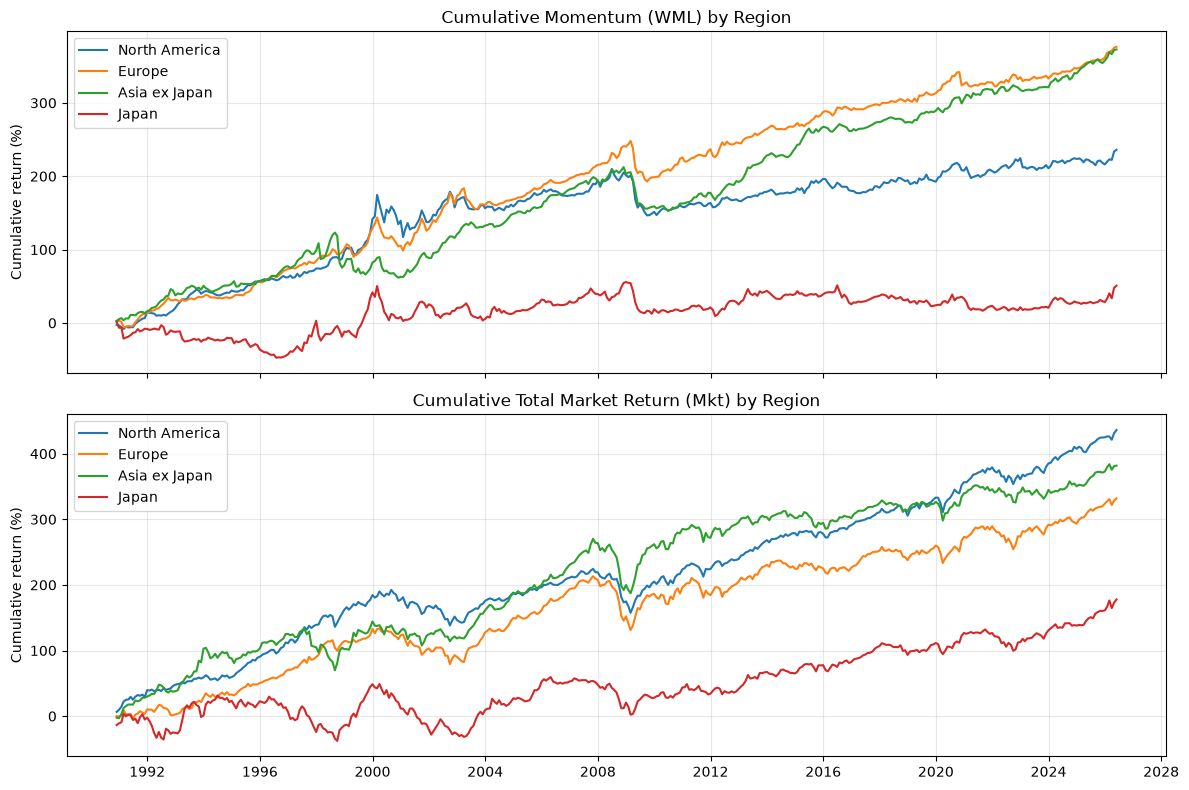

In [20]:
mkt_cols = [col for col in factors_df.columns if col.endswith("_Mkt")]
wml_cols = [col for col in factors_df.columns if col.endswith("_WML")]

growth = (1 + factors_df / 100).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for column in wml_cols:
    axes[0].plot(growth.index, growth[column], label=column.replace("_WML", ""))

axes[0].set_title("Momentum (WML) — Growth of $1 (compounded)")
axes[0].set_ylabel("Growth of $1")
axes[0].set_yscale("log")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)

for column in mkt_cols:
    axes[1].plot(growth.index, growth[column], label=column.replace("_Mkt", ""))

axes[1].set_title("Total Market (Mkt) — Growth of $1 (compounded)")
axes[1].set_ylabel("Growth of $1")
axes[1].set_yscale("log")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()